In [1]:
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

batch_size = 64
latent_dim = 100

# Pipeline para o CelebA (64x64 RGB)
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64), # Corta o centro para deixar o rosto em evidência
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# O caminho que você copiou, apontando diretamente para a pasta de imagens
caminho_kaggle = '/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba'

# Usamos o ImageFolder, que é perfeito para ler pastas cheias de imagens .jpg
dataset = dset.ImageFolder(root=caminho_kaggle, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Total de imagens carregadas: {len(dataset)}")

Total de imagens carregadas: 202599


In [2]:
import torch
import torch.nn as nn

# Configuração de dispositivo (GPU se disponível)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            # Projeta o ruído (100) numa base 4x4 com 512 canais
            nn.Linear(latent_dim, 512 * 4 * 4),
            nn.BatchNorm1d(512 * 4 * 4),
            nn.ReLU(True),
            nn.Unflatten(1, (512, 4, 4)),
            
            # 4x4 -> 8x8
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            # 8x8 -> 16x16
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # 16x16 -> 32x32
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # 32x32 -> 64x64 (e 3 canais de cor RGB)
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

In [3]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # 64x64 (3 canais) -> 32x32
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 32x32 -> 16x16
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 16x16 -> 8x8
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 8x8 -> 4x4
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Classificação Final
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

In [4]:
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

batch_size = 64

# Pipeline de transformação para 64x64
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Caminho do dataset no Kaggle
caminho_kaggle = '/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba'

# Carregando os dados
dataset = dset.ImageFolder(root=caminho_kaggle, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Dataloader pronto! Total de imagens: {len(dataset)}")
print(f"Total de lotes (batches) por época: {len(dataloader)}")

Dataloader pronto! Total de imagens: 202599
Total de lotes (batches) por época: 3166


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
from torchvision.utils import save_image

latent_dim = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recriando os modelos do zero para "resetar" os cérebros deles
generator = Generator().to(device)
discriminator = Discriminator().to(device)

learning_rate = 0.0002
criterion = nn.BCELoss().to(device)
optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

os.makedirs('/kaggle/working/images_celeba', exist_ok=True)

epochs = 20 # Se quiser, pode aumentar para 30 ou 40 para ver mais detalhes!
print("Iniciando o treinamento na", device, "com Label Smoothing...")

for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        
        real_imgs = imgs.to(device)
        batch_size_atual = real_imgs.size(0)
        
        # -----------------------------------------------------------
        # O SEGREDO DO LABEL SMOOTHING ESTÁ AQUI:
        # Em vez de 1.0, usamos 0.9 para as imagens reais!
        real_labels = (torch.ones(batch_size_atual, 1) * 0.9).to(device)
        fake_labels = torch.zeros(batch_size_atual, 1).to(device)
        # -----------------------------------------------------------

        # Treinar Discriminador
        optimizer_D.zero_grad()
        real_loss = criterion(discriminator(real_imgs), real_labels)
        
        z = torch.randn(batch_size_atual, latent_dim).to(device)
        fake_imgs = generator(z)
        fake_loss = criterion(discriminator(fake_imgs.detach()), fake_labels)
        
        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # Treinar Gerador
        optimizer_G.zero_grad()
        # O Gerador tenta alcançar o 0.9
        g_loss = criterion(discriminator(fake_imgs), real_labels)
        g_loss.backward()
        optimizer_G.step()

        if i % 400 == 0:
            print(f"Epoch [{epoch}/{epochs}] Batch {i}/{len(dataloader)} Loss D: {d_loss.item():.4f}, Loss G: {g_loss.item():.4f}")

    save_image(fake_imgs[:25], f"/kaggle/working/images_celeba/dcgan_epoch_{epoch}.png", nrow=5, normalize=True)

print("Treinamento finalizado com sucesso!")

Iniciando o treinamento na cuda com Label Smoothing...
Epoch [0/20] Batch 0/3166 Loss D: 1.3965, Loss G: 2.7831
Epoch [0/20] Batch 400/3166 Loss D: 0.5299, Loss G: 4.0840
Epoch [0/20] Batch 800/3166 Loss D: 1.0286, Loss G: 8.1720
Epoch [0/20] Batch 1200/3166 Loss D: 0.5863, Loss G: 2.5876
Epoch [0/20] Batch 1600/3166 Loss D: 0.4647, Loss G: 3.7376
Epoch [0/20] Batch 2000/3166 Loss D: 0.6369, Loss G: 5.0929
Epoch [0/20] Batch 2400/3166 Loss D: 0.6832, Loss G: 2.0922
Epoch [0/20] Batch 2800/3166 Loss D: 0.5746, Loss G: 3.3593
Epoch [1/20] Batch 0/3166 Loss D: 1.4979, Loss G: 2.2462
Epoch [1/20] Batch 400/3166 Loss D: 1.0122, Loss G: 6.3677
Epoch [1/20] Batch 800/3166 Loss D: 1.1822, Loss G: 2.7115
Epoch [1/20] Batch 1200/3166 Loss D: 0.5571, Loss G: 3.3347
Epoch [1/20] Batch 1600/3166 Loss D: 0.6170, Loss G: 3.3087
Epoch [1/20] Batch 2000/3166 Loss D: 0.5988, Loss G: 3.1291
Epoch [1/20] Batch 2400/3166 Loss D: 0.4175, Loss G: 3.8059
Epoch [1/20] Batch 2800/3166 Loss D: 0.6035, Loss G: 2.

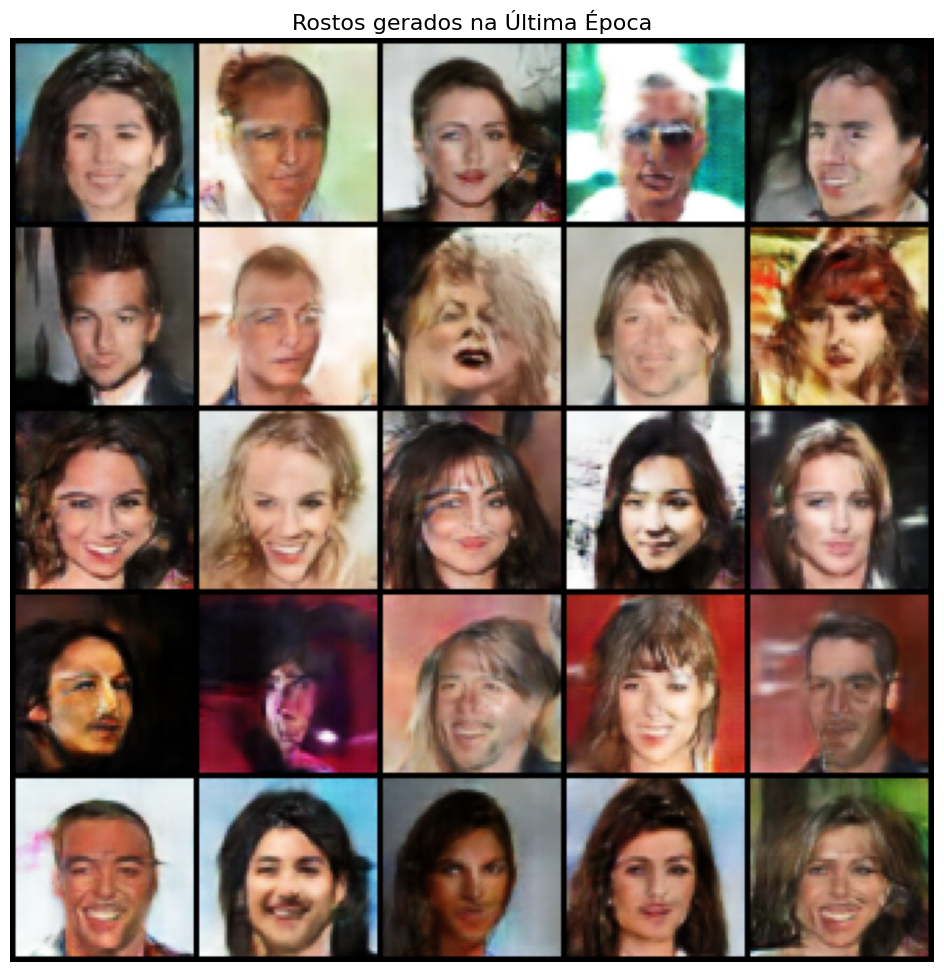

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Vamos carregar a imagem da última época (se você treinou 20 épocas, a última é a 19)
caminho_imagem = '/kaggle/working/images_celeba/dcgan_epoch_19.png'

# Lendo e plotando a imagem
img = mpimg.imread(caminho_imagem)
plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis('off') # Esconde os números dos eixos para ficar mais bonito
plt.title("Rostos gerados na Última Época", fontsize=16)
plt.show()